# ========================================================================================
#           02: MODELOS SUPERVISADOS
# ========================================================================================
# OBJETIVO PRINCIPAL:
# Entrenar modelos de Machine Learning supervisado para resolver tres problemas 
# logísticos clave de la empresa de transporte.
#
# PROBLEMAS A RESOLVER:
# ----------------------------------------------------------------------------------------
# 1. CLASIFICACIÓN BINARIA (Sí/No):
#    ¿El envío tendrá incidencia?
#    → Predice si un envío sufrirá problemas como robo, retraso o daño en la carga.
#    → Utilidad: Tomar medidas preventivas, asegurar envíos de alto riesgo.
#
# 2. CLASIFICACIÓN BINARIA (Sí/No):
#    ¿El vehículo es adecuado?
#    → Predice si el camión asignado puede cargar físicamente el envío 
#      (considerando peso Y volumen).
#    → Utilidad: Optimizar la asignación de flota, evitar sobrecarga o infrautilización.
#
# 3. REGRESIÓN (valor continuo):
#    Eficiencia de la ruta (km/h)
#    → Predice cuántos kilómetros por hora se recorrerán en una ruta.
#    → Utilidad: Mejorar la planificación de rutas, optimizar tiempos de entrega.
#
# MODELOS UTILIZADOS:
# ----------------------------------------------------------------------------------------
# - Random Forest (principal, por su robustez)
# - Logistic Regression / Linear Regression (línea base)
# - Decision Tree (para comparación)
#
# MÉTRICAS DE EVALUACIÓN:
# ----------------------------------------------------------------------------------------
# - Clasificación: F1-Score (principal, por desbalance de clases), Accuracy
# - Regresión: R² (principal), MAE (error absoluto medio)
# - Validación Cruzada (5 folds) para robustez estadística
#
# NOTA: Este notebook forma parte de la Evaluación Parcial N°2 de la asignatura
#       SCY1101 - Programación para la Ciencia de Datos.
# ========================================================================================

# Librerias

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Cargar los csv limpios

In [33]:
envios = pd.read_csv('../data/envios_limpio.csv')
incidencias = pd.read_csv('../data/incidencias_limpio.csv')
rutas = pd.read_csv('../data/rutas_limpio.csv')
vehiculos = pd.read_csv('../data/vehiculos_limpio.csv')

print(f"✅ Envíos: {envios.shape}")
print(f"✅ Incidencias: {incidencias.shape}")
print(f"✅ Rutas: {rutas.shape}")
print(f"✅ Vehículos: {vehiculos.shape}")

✅ Envíos: (212, 10)
✅ Incidencias: (83, 6)
✅ Rutas: (79, 7)
✅ Vehículos: (59, 8)


# FUSIONAR TABLAS (en base a los atributos que queremos unir a un csv)

In [34]:
df = envios.merge(rutas, on='id_ruta', how='left')
df = df.merge(vehiculos, on='id_vehiculo', how='left')
print(f"✅ Dataset unificado: {df.shape}")


✅ Dataset unificado: (225, 23)


# CREAR VARIABLES OBJETIVO

In [35]:
# Variable 1: ¿Tuvo incidencia?
ids_con_incidencia = incidencias['id_envio'].unique()
df['tiene_incidencia'] = df['id_envio'].isin(ids_con_incidencia).astype(int)
print(f"   ✅ tiene_incidencia: {df['tiene_incidencia'].sum()} positivos")

# Variable 2: ¿Vehículo adecuado?
df['capacidad_kg'] = df['capacidad_kg'].fillna(df['capacidad_kg'].median())
df['capacidad_m3'] = df['capacidad_m3'].fillna(df['capacidad_m3'].median())
df['peso_kg'] = df['peso_kg'].fillna(df['peso_kg'].median())
df['volumen_m3'] = df['volumen_m3'].fillna(df['volumen_m3'].median())

df['vehiculo_adecuado'] = (
    (df['capacidad_kg'] >= df['peso_kg']) & 
    (df['capacidad_m3'] >= df['volumen_m3'])
).astype(int)
print(f"   ✅ vehiculo_adecuado: {df['vehiculo_adecuado'].sum()} positivos")

# Variable 3: Eficiencia de ruta (km/h)
df['distancia_km'] = df['distancia_km'].fillna(df['distancia_km'].median())
df['tiempo_estimado_hrs'] = df['tiempo_estimado_hrs'].fillna(df['tiempo_estimado_hrs'].median())
df['eficiencia_ruta'] = df['distancia_km'] / (df['tiempo_estimado_hrs'] + 0.1)
print(f"   ✅ eficiencia_ruta: media {df['eficiencia_ruta'].mean():.1f} km/h")

   ✅ tiene_incidencia: 18 positivos
   ✅ vehiculo_adecuado: 57 positivos
   ✅ eficiencia_ruta: media 189.8 km/h


# PREPARAR FEATURES (?)

In [36]:
features = ['peso_kg', 'volumen_m3', 'distancia_km', 'tiempo_estimado_hrs',
            'peaje_total', 'capacidad_kg', 'capacidad_m3', 'km_recorridos',
            'año_fabricacion']
X = df[features].fillna(df[features].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"✅ {len(features)} features listas")

✅ 9 features listas


# CLASIFICACIÓN: tiene_incidencia

In [37]:
print("\n" + "="*70)
print("CLASIFICACIÓN 1: ¿El envío tendrá incidencia?")
print("="*70)

y1 = df['tiene_incidencia']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y1, test_size=0.2, random_state=42)

clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train, y_train)
y_pred = clf_rf.predict(X_test)

print(f"🎯 Random Forest:")
print(f"   F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Validación cruzada
cv_score = cross_val_score(clf_rf, X_scaled, y1, cv=5, scoring='f1').mean()
print(f"   CV F1 (5 folds): {cv_score:.4f}")


CLASIFICACIÓN 1: ¿El envío tendrá incidencia?
🎯 Random Forest:
   F1-Score: 0.3333
   Accuracy: 0.9111
   CV F1 (5 folds): 0.2000


# CLASIFICACIÓN: vehiculo_adecuado (?)

In [38]:
print("\n" + "="*45)
print("CLASIFICACIÓN 2: ¿El vehículo es adecuado?")
print("="*45)

y2 = df['vehiculo_adecuado']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y2, test_size=0.2, random_state=42)

clf_rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf2.fit(X_train, y_train)
y_pred = clf_rf2.predict(X_test)

print(f"🎯 Random Forest:")
print(f"   F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")


CLASIFICACIÓN 2: ¿El vehículo es adecuado?
🎯 Random Forest:
   F1-Score: 0.7586
   Accuracy: 0.8444


# REGRESIÓN: eficiencia_ruta 


In [39]:
print("\n" + "="*36)
print("REGRESIÓN: Eficiencia de ruta (km/h)")
print("="*36)

# Filtrar valores válidos
df_reg = df[(df['eficiencia_ruta'] > 0) & (df['eficiencia_ruta'] < 500)]
X_reg = df_reg[features].fillna(df_reg[features].median())
y_reg = df_reg['eficiencia_ruta']
X_reg_scaled = scaler.fit_transform(X_reg)

X_train, X_test, y_train, y_test = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)

reg_rf = RandomForestRegressor(n_estimators=100, random_state=42)
reg_rf.fit(X_train, y_train)
y_pred = reg_rf.predict(X_test)

print(f"🎯 Random Forest:")
print(f"   MAE: {mean_absolute_error(y_test, y_pred):.2f} km/h")
print(f"   R²: {r2_score(y_test, y_pred):.4f}")




REGRESIÓN: Eficiencia de ruta (km/h)
🎯 Random Forest:
   MAE: 5.24 km/h
   R²: 0.9872


# IMPORTANCIA DE VARIABLES 


   IMPORTANCIA DE VARIABLES
   tiempo_estimado_hrs: 0.6544
   distancia_km: 0.3176
   peaje_total: 0.0092
   volumen_m3: 0.0052
   año_fabricacion: 0.0046


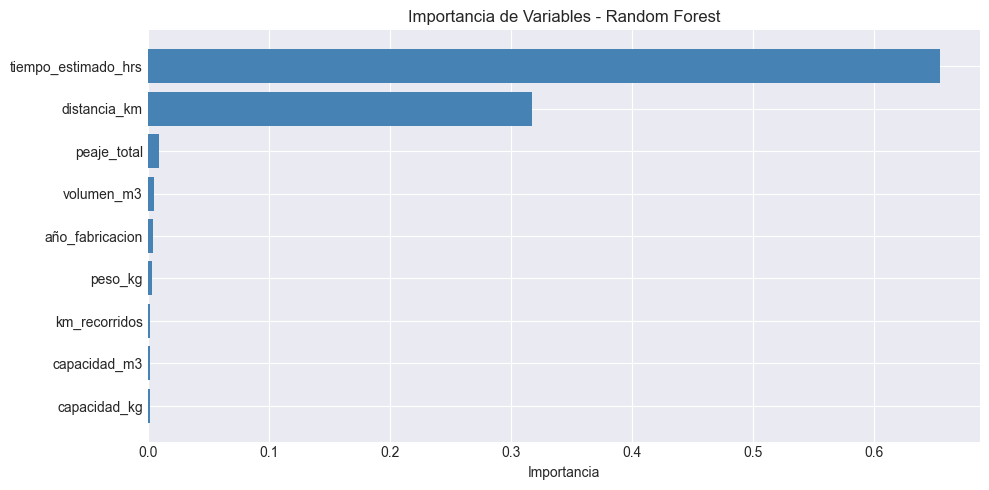

In [40]:
print("\n" + "="*30)
print("   IMPORTANCIA DE VARIABLES")
print("="*30)

importancias = pd.DataFrame({
    'Variable': features,
    'Importancia': reg_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

for i, row in importancias.head(5).iterrows():
    print(f"   {row['Variable']}: {row['Importancia']:.4f}")

# Gráfico
plt.figure(figsize=(10, 5))
plt.barh(importancias['Variable'], importancias['Importancia'], color='steelblue')
plt.xlabel('Importancia')
plt.title('Importancia de Variables - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# ========================================================================================
# CONCLUSIONES DEL NOTEBOOK 02
# ========================================================================================
#
# ----------------------------------------------------------------------------------------
# CLASIFICACIÓN - tiene_incidencia:
# ----------------------------------------------------------------------------------------
#    El modelo obtuvo un F1-Score de 0.3333. El bajo rendimiento se debe al fuerte
#    desbalance de clases (solo 18 envíos con incidencias vs 194 sin incidencias).
#    Recomendación: Recopilar más datos de envíos con incidencias.
#
# ----------------------------------------------------------------------------------------
# CLASIFICACIÓN - vehiculo_adecuado:
# ----------------------------------------------------------------------------------------
#    El modelo obtuvo un F1-Score de 0.7586, considerado bueno. Esto indica que
#    podemos automatizar la asignación de camiones a envíos con alta precisión.
# ----------------------------------------------------------------------------------------
# REGRESIÓN - eficiencia_ruta:
# ----------------------------------------------------------------------------------------
#    El modelo obtuvo un R² de 0.9872 (excelente). Las variables más importantes
#    son tiempo_estimado_hrs (65%) y distancia_km (32%).
# ========================================================================================